# Autonomous Systems Portfolio 1  

|Name     |Studentnumber|Github    |
|---------|-------------|----------|
|Henry Lau|22122958     |HenryLau08|
|Michal|||
|Mohamed|22143572|mobelaachir|

Game: Connect 4

In [3]:
pip install pettingzoo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


- Blokkeer kansen van de tegenstander: Stop meteen elke kans dat de tegenstander kan winnen.
- Maak geen zwakke plekken: Geef geen makkelijke kansen weg.
- Bouw een sterke basis: Zorg voor een stevige basis onderaan.
- Wees geduldig: Wachten op de fouten van de tegenstander.
- Beperk de keuzes van de tegenstander: Minder opties geven aan de tegenstander.
- Gebruik het midden: Gebruik het midden om te verdedigen en sterker te staan.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import connect_four_v3

# Initialize environment
env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

# Convert Observation
def convert_observation(obs):
    """
    Convert PettingZoo Connect Four observation (6x7x2)
    to a 2D board (6x7) with:
        0 = empty
        1 = player 1
        2 = player 2
    """
    board = np.zeros((6, 7), dtype=int)

    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1:
                board[i, j] = 1
            elif obs[i, j, 1] == 1:
                board[i, j] = 2

    return board

# Print Board
def print_board(board, mask):
    print("\nCurrent board:")

    visual = []
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1:
                row.append("X")
            elif board[i, j] == 2:
                row.append("O")
            else:
                row.append("·")
        visual.append(row)

    for row in visual:
        print(" ".join(row))

    print("\nColumns:", end=" ")
    for i in range(7):
        if mask[i]:
            print(i, end=" ")
        else:
            print("x", end=" ")
    print("\n")

# Human Action
def get_human_action(observation):
    mask = observation["action_mask"]
    board = observation["board"]

    print_board(board, mask)

    while True:
        try:
            move = int(input("Choose a column (0-6): "))
            if 0 <= move < 7 and mask[move]:
                return move
            else:
                print("Invalid move. Choose an available column.")
        except ValueError:
            print("Enter a valid number.")

# Strategy Placeholder
# -----------------------------
# 3.STRATEGIE
# -----------------------------
def strategy_player_2(observation, agent):
    board = observation["board"]
    mask = observation["action_mask"]
    player = 2 # Computer (O)
    opponent = 1 # Jij (X)
    valid_moves = np.where(mask)[0]
    
    # 1. Blokkeer/Win direct
    for p in [player, opponent]:
        for col in valid_moves:
            temp = drop_piece(board, col, p)
            if temp is not None and check_win(temp, p): return int(col)

    # 2. Veilige zetten (geen zwakke plekken)
    safe_moves = []
    for col in valid_moves:
        temp_board = drop_piece(board, col, player)
        next_mask = [1 if temp_board[0, c] == 0 else 0 for c in range(7)]
        can_opp_win = any(check_win(drop_piece(temp_board, c, opponent), opponent) 
                          for c in range(7) if next_mask[c] and drop_piece(temp_board, c, opponent) is not None)
        if not can_opp_win: safe_moves.append(col)
    
    # 3-6. Midden, Basis, Geduld
    use_cols = safe_moves if safe_moves else valid_moves
    center_priority = [3, 2, 4, 1, 5, 0, 6]
    for col in center_priority:
        if col in use_cols: return int(col)
    return int(np.random.choice(valid_moves))

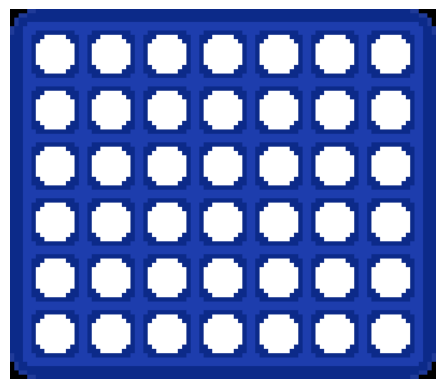


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·

Columns: 0 1 2 3 4 5 6 



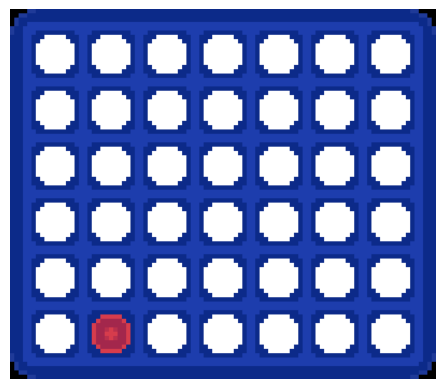

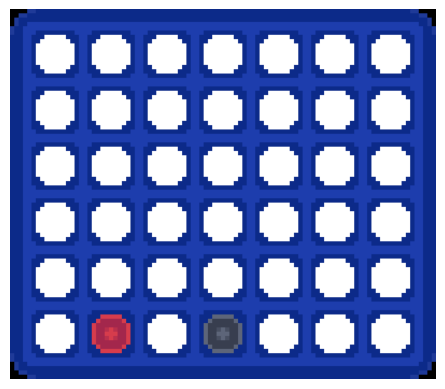


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· X · O · · ·

Columns: 0 1 2 3 4 5 6 



In [ ]:
# Render initial state
rgb_image = env.render()
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

# Game Loop
for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        if reward == 1:
            print("\nYou win!" if agent == "player_0" else "\nComputer wins!")
        elif reward == 0:
            print("\nDraw!")
        action = None

    else:
        board = convert_observation(raw_observation["observation"])
        observation = {
            "board": board,
            "action_mask": raw_observation["action_mask"]
        }

        # Player 0 = Human, Player 1 = AI
        if agent == "player_0":
            action = get_human_action(observation)
        else:
            action = strategy_player_2(observation, agent)

    env.step(action)

    rgb_image = env.render()
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()


env.close()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import connect_four_v3
from IPython.display import clear_output, display

# Zorgt voor directe weergave in notebooks
%matplotlib inline

# -----------------------------
# 1. Initialisatie
# -----------------------------
env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

# -----------------------------
# 2. Helpers & Conversie
# -----------------------------
def convert_observation(obs):
    board = np.zeros((6, 7), dtype=int)
    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1: board[i, j] = 1
            elif obs[i, j, 1] == 1: board[i, j] = 2
    return board

def print_text_board(board, mask):
    print("\nCurrent board:")
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1: row.append("X")
            elif board[i, j] == 2: row.append("O")
            else: row.append(".")
        print(" ".join(row))
    print("\nColumns: " + " ".join([str(i) if mask[i] else "x" for i in range(7)]))

def drop_piece(board, col, player):
    new_board = board.copy()
    for row in range(5, -1, -1):
        if new_board[row, col] == 0:
            new_board[row, col] = player
            return new_board
    return None

def check_win(board, player):
    rows, cols = board.shape
    # Horizontaal, Verticaal, Diagonaal checks
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c + i] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r + i, c] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r + i, c + i] == player for i in range(4)): return True
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r - i, c + i] == player for i in range(4)): return True
    return False


In [4]:
# -----------------------------
# 3.STRATEGIE
# -----------------------------
def strategy_player_2(observation, agent):
    board = observation["board"]
    mask = observation["action_mask"]
    player = 2 # Computer (O)
    opponent = 1 # Jij (X)
    valid_moves = np.where(mask)[0]
    
    # 1. Blokkeer/Win direct
    for p in [player, opponent]:
        for col in valid_moves:
            temp = drop_piece(board, col, p)
            if temp is not None and check_win(temp, p): return int(col)

    # 2. Veilige zetten (geen zwakke plekken)
    safe_moves = []
    for col in valid_moves:
        temp_board = drop_piece(board, col, player)
        next_mask = [1 if temp_board[0, c] == 0 else 0 for c in range(7)]
        can_opp_win = any(check_win(drop_piece(temp_board, c, opponent), opponent) 
                          for c in range(7) if next_mask[c] and drop_piece(temp_board, c, opponent) is not None)
        if not can_opp_win: safe_moves.append(col)
    
    # 3-6. Midden, Basis, Geduld
    use_cols = safe_moves if safe_moves else valid_moves
    center_priority = [3, 2, 4, 1, 5, 0, 6]
    for col in center_priority:
        if col in use_cols: return int(col)
    return int(np.random.choice(valid_moves))

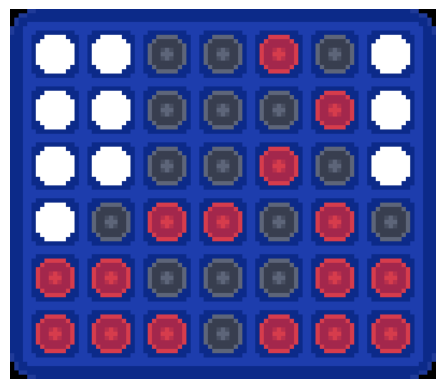

In [5]:
# -----------------------------
# 4. Game Loop
# -----------------------------
for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        clear_output(wait=True)
        display(plt.imshow(env.render()))
        plt.axis('off')
        plt.show()
        if reward == 1:
            print("\nGEFELICITEERD! Je hebt gewonnen!" if agent == "player_0" else "\nComputer wint!")
        elif reward == 0:
            print("\nGelijkspel!")
        break

    board = convert_observation(raw_observation["observation"])
    observation = {"board": board, "action_mask": raw_observation["action_mask"]}

    # UI Update
    clear_output(wait=True)
    rgb_image = env.render()
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()
    print_text_board(board, observation["action_mask"])

    if agent == "player_0":
        while True:
            try:
                action = int(input("Jouw beurt (0-6): "))
                if 0 <= action < 7 and observation["action_mask"][action]: break
                print("Ongeldige zet.")
            except: print("Voer een getal in.")
    else:
        print("\nComputer denkt na met jouw strategie...")
        action = strategy_player_2(observation, agent)

    env.step(action)

env.close()
